This notebook creates a sentiment analysis machine learning model designed to predict whether an IMDB review is positive or negative. The notebook will load and save files from your google drive.

The input file should be formatted with the following:
1. A "review" column
2. A "sentiment" column with either "positive" or "negative"

## AutoModel Test

From https://huggingface.co/docs/transformers/main/en/model_doc/modernbert?usage=AutoModel

In [ ]:
# # ! pip install transformers
# # ! pip install torch

# import torch
# from transformers import AutoModelForMaskedLM, AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained(
#     "answerdotai/ModernBERT-base",
# )
# model = AutoModelForMaskedLM.from_pretrained(
#     "answerdotai/ModernBERT-base",
#     torch_dtype=torch.float16,
#     device_map="auto",
#     attn_implementation="sdpa"
# )
# inputs = tokenizer("Plants create [MASK] through a process known as photosynthesis.", return_tensors="pt").to("cpu") # replaced from cuda. we do not have nvidia gpus

# with torch.no_grad():
#     outputs = model(**inputs)
#     predictions = outputs.logits

# masked_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]
# predicted_token_id = predictions[0, masked_index].argmax(dim=-1)
# predicted_token = tokenizer.decode(predicted_token_id)

# print(f"The predicted token is: {predicted_token}")

# **Sentiment Analysis Model Training**

### Preparing Tools and Files

In [ ]:
# ! pip install torch
# ! pip install transformers
# ! pip install numpy
# ! pip install pandas

In [ ]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ColabMount/SentimentAnalysis/imdb_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Preprocessing

The goal of preprocessing it to turn human-readable data into computer-readable training data.

First, we will check the dataset for missing parameters and remove them. In other cases, the blank values can often be replaced with values like the mode, but we have enough entries to ignore this.

In [ ]:
df.isna().sum()

# # For replacement with column mode
# modes = df.mode().iloc[0]
# df.fillna(modes, inplace=True)
# df.isna().sum()

,0
review,0
sentiment,0


No blank entries!

 Now, we're going to trim down this dataset. This model is for learning purposes and doesn't need that much data.

In [ ]:
df.drop(df.index[1000:], inplace=True)
df['sentiment'].value_counts() # Checking to ensure that there's a good balance between positive and negative reviews for training

,count
sentiment,
positive,501
negative,499


Next, we're going to convert the positive and negative sentiments into boolean integers

In [ ]:
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


Next, we'll tokenize the words. This takes the words and turns them into "tokens", chunks of information that can be read and understood by the computer.

In [ ]:
from datasets import Dataset
dataset = Dataset.from_pandas(df)

tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base",)
def tokenize(batch):
    return tokenizer(batch["review"], padding=True, truncation=True, max_length=128)

# Apply tokenizer
dataset_enc = dataset.map(tokenize, batched=True, remove_columns=["review", "sentiment"])
dataset_enc = dataset_enc.train_test_split(test_size=0.2)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Next, we want to convert these to pytorch tensors, objects that can be read by the pytorch library.

In [ ]:
dataset_enc.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

The last few tools are the dataloaders and collators.

* The dataloaders will make sure we're sending small batches of reviews/sentiments. The training data will be shuffled, making sure that the model isn't training for unintended patterns, such as the spreadsheet alternating between positive and negative reviews, and making guesses based on that.

* The collator helps with efficiency of space and time by increasing the size of all tokens to the largest token in the batch.

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Dataloaders
train_dataloader = DataLoader(
    dataset_enc["train"], shuffle=True, batch_size=8, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    dataset_enc["test"], batch_size=5, collate_fn=data_collator
)

## Processing

First we load the model to be trained.

In [ ]:
num_labels = 2 # positive and negative, or 1 and 0
model = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base", num_labels=num_labels
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Now let's define some parameters for how the model will train.

* learning rate: how much the model will adjust it's weights based on errorr.

* epochs: how many times the model will go through the entire dataset.

**Training is made up of epochs, epochs are made up of batches, batches are made of up of entries.**

In [ ]:
learning_rate = 5e-5
num_epochs = 5

We'll set up a dynamic learning rate, shrinking over time as we get closer. Our first few runs will be rough, but as it gets better at prediction (lower loss), we want our adjustments to be smaller with it.

In [ ]:
optimizer = AdamW(model.parameters(), lr=learning_rate)
num_training_batches = len(train_dataloader)
num_training_steps = num_epochs * num_training_batches
lr_scheduler = get_scheduler("linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

Now we specify which part of the computer will process this. Ideally a gpu, or alternatively a cpu.

a TPU is an ai GPU, basically. Make sure to go to runtime and swap to a gpu or tpu

to cut the time taken, you can cut the num_epochs and the size of the input data

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
progress_bar = tqdm(range(num_training_steps)) # for convenience
model.train()

  0%|          | 0/500 [00:00<?, ?it/s]

ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      

Training Loop:

1.

Epoch 1 of 5


W0814 19:24:08.448000 675 torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode
 20%|██        | 100/500 [00:36<01:46,  3.76it/s]

Average Loss: 0.5424
Epoch 2 of 5


 40%|████      | 200/500 [01:04<01:25,  3.51it/s]

Average Loss: 0.1799
Epoch 3 of 5


...

Average Loss: 0.0317
Epoch 4 of 5


 80%|████████  | 400/500 [01:59<00:28,  3.54it/s]

Average Loss: 0.0101
Epoch 5 of 5


100%|██████████| 500/500 [02:27<00:00,  3.57it/s]

Average Loss: 0.0022


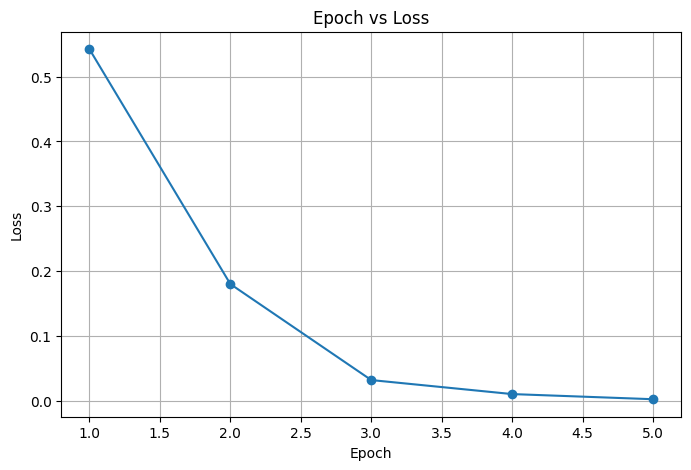

In [ ]:
import matplotlib.pyplot as plt

train_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1} of {num_epochs}")
    running_loss = 0.0

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        progress_bar.update(1)

    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.grid(True)
plt.show()


To keep persistent, mount google drive and save the weights to a file

In [ ]:
model_save_path = '/content/drive/MyDrive/ColabMount/SentimentAnalysis/imdb_trained'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

('/content/drive/MyDrive/ColabMount/SentimentAnalysis/imdb_trained/tokenizer_config.json',
 '/content/drive/MyDrive/ColabMount/SentimentAnalysis/imdb_trained/special_tokens_map.json',
 '/content/drive/MyDrive/ColabMount/SentimentAnalysis/imdb_trained/tokenizer.json')